# Лабораторне заняття №0
## Налаштування робочого середовища та основи роботи з pandas
Студент: Абдулханов Абдул-Рахім, група ФеП-33

### 1. Порівняння середовищ розробки
| Характеристика | PyCharm | Jupyter Notebook | Google Colab |
| --- | --- | --- | --- |
| Потрібне встановлення | Так | Так | Ні |
| Потрібен Python на ПК | Так | Так | Ні |
| Основний формат файлів | .py | .ipynb | .ipynb |
| Виконання коду | Повний скрипт | По окремих комірках | По окремих комірках |
| Спільний доступ | Через VCS (Git) | Локальний файл | Пряме посилання в хмарі |

In [1]:
# імпортуємо бібліотеки для роботи з даними
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print('pandas version:', pd.__version__)

pandas version: 3.0.6


### 2. Зчитування даних та дослідження параметрів
Датасет iris1.csv містить 150 спостережень за трьома видами ірисів (Setosa, Versicolor, Virginica) з чотирма морфологічними ознаками (довжина та ширина чашолистка і пелюстки).

In [2]:
# зчитуємо дані (локально або автоматично завантажуємо в Colab)
if os.path.exists('task/iris1.csv'):
    csv_src = 'task/iris1.csv'
elif os.path.exists('iris1.csv'):
    csv_src = 'iris1.csv'
else:
    csv_src = 'https://raw.githubusercontent.com/RakhimAbdulkhanov/data_engineering/main/lab0/task/iris1.csv'

df = pd.read_csv(csv_src)
print('shape:', df.shape)
print('columns:', df.columns.tolist())
print('index:', df.index)
print('dtypes:\n', df.dtypes)
df.info()
print('\nhead(3):\n', df.head(3))
print('\ntail(3):\n', df.tail(3))
print('\nsample(3):\n', df.sample(3, random_state=42))

shape: (150, 5)
columns: ['sepal.length', 'sepal.width', 'petal.length', 'petal.width', 'variety']
index: RangeIndex(start=0, stop=150, step=1)
dtypes:
 sepal.length    float64
sepal.width     float64
petal.length    float64
petal.width     float64
variety             str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

head(3):
    sepal.length  sepal.width  petal.length  petal.width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa

tai

### 3. Створення нових колонок, вибірка, індексація, drop та query

In [3]:
# створення колонки суми двох колонок та їх співвідношення
df['total_length'] = df['sepal.length'] + df['petal.length']
df['sepal_ratio'] = (df['sepal.length'] / df['sepal.width']).round(2)
print('нова колонка суми total_length:\n', df[['sepal.length', 'petal.length', 'total_length']].head(3))

# вибірка loc та iloc
print('\nloc subset:\n', df.loc[:2, ['sepal.length', 'variety']])
print('\niloc subset:\n', df.iloc[:2, [0, 2]])

# встановлення індексу set_index та видалення стовпця drop
df_indexed = df.set_index('variety')
print('\nset_index preview:\n', df_indexed.head(2))
df_dropped = df.drop(columns=['total_length'])
print('columns after drop:', df_dropped.columns.tolist())

# умовна фільтрація та метод query
print('setosa count:', len(df[df['variety'] == 'Setosa']))
query_res = df.query('`sepal.length` > 6.0 and variety == "Virginica"')
print('query count (>6.0 and Virginica):', len(query_res))

нова колонка суми total_length:
    sepal.length  petal.length  total_length
0           5.1           1.4           6.5
1           4.9           1.4           6.3
2           4.7           1.3           6.0

loc subset:
    sepal.length variety
0           5.1  Setosa
1           4.9  Setosa
2           4.7  Setosa

iloc subset:
    sepal.length  petal.length
0           5.1           1.4
1           4.9           1.4

set_index preview:
          sepal.length  sepal.width  petal.length  petal.width  total_length  \
variety                                                                       
Setosa            5.1          3.5           1.4          0.2           6.5   
Setosa            4.9          3.0           1.4          0.2           6.3   

         sepal_ratio  
variety               
Setosa          1.46  
Setosa          1.63  
columns after drop: ['sepal.length', 'sepal.width', 'petal.length', 'petal.width', 'variety', 'sepal_ratio']
setosa count: 50
query count (>6.0 an

### 4. Summary Functions, Maps та Lambda вирази

In [4]:
# частоти, унікальні, сума, середнє
print('value_counts:\n', df['variety'].value_counts())
print('unique:', df['variety'].unique())
print('sum petal length:', round(df['petal.length'].sum(), 2))
print('mean sepal length:', round(df['sepal.length'].mean(), 2))

# map зі словником та лямбда функцією
species_code = {'Setosa': 0, 'Versicolor': 1, 'Virginica': 2}
df['species_id'] = df['variety'].map(species_code)
df['variety_upper'] = df['variety'].map(lambda x: str(x).upper())
df[['variety', 'species_id', 'variety_upper']].head(3)

value_counts:
 variety
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64
unique: <StringArray>
['Setosa', 'Versicolor', 'Virginica']
Length: 3, dtype: str
sum petal length: 563.7
mean sepal length: 5.84


,variety,species_id,variety_upper
0,Setosa,0,SETOSA
1,Setosa,0,SETOSA
2,Setosa,0,SETOSA


### 5. Групування за 1, 2, 3 колонками, сортування та вплив параметрів

In [5]:
# сортування ascending=True та False
print('sort ascending:\n', df.sort_values(by='sepal.length', ascending=True)[['sepal.length', 'variety']].head(2))
print('sort descending:\n', df.sort_values(by='sepal.length', ascending=False)[['sepal.length', 'variety']].head(2))

# квантильні категорії для багатовимірного групування
df['sepal_cat'] = pd.qcut(df['sepal.length'], q=3, labels=['short', 'medium', 'long'])
df['petal_cat'] = pd.qcut(df['petal.length'], q=2, labels=['small', 'large'])

# групування за 1, 2 та 3 колонками
print('\ngrouped by 1 col:\n', df.groupby('variety')['sepal.length'].mean().round(2))
print('\ngrouped by 2 cols:\n', df.groupby(['variety', 'sepal_cat'], observed=False)['petal.length'].mean().round(2))
grp_3 = df.groupby(['variety', 'sepal_cat', 'petal_cat'], observed=False)['sepal.width'].agg(['count', 'mean']).dropna()
print('\ngrouped by 3 cols:\n', grp_3.head(6))

# багатопараметрична агрегація agg
agg_res = df.groupby('variety').agg({'sepal.length': ['mean', 'max', 'min'], 'petal.length': ['mean', 'std']}).round(2)
print('\nmulti-parameter agg:\n', agg_res)

# демонстрація впливу параметрів (2 приклади)
print('\nas_index=True type:', type(df.groupby('variety', as_index=True)['petal.length'].mean()))
print('as_index=False type:', type(df.groupby('variety', as_index=False)['petal.length'].mean()))

sort ascending:
     sepal.length variety
13           4.3  Setosa
42           4.4  Setosa
sort descending:
      sepal.length    variety
131           7.9  Virginica
135           7.7  Virginica

grouped by 1 col:
 variety
Setosa        5.01
Versicolor    5.94
Virginica     6.59
Name: sepal.length, dtype: float64

grouped by 2 cols:
 variety     sepal_cat
Setosa      short        1.47
            medium       1.42
            long          NaN
Versicolor  short        3.58
            medium       4.26
            long         4.63
Virginica   short        4.50
            medium       5.17
            long         5.81
Name: petal.length, dtype: float64

grouped by 3 cols:
                                 count      mean
variety    sepal_cat petal_cat                 
Setosa     short     small         45  3.366667
           medium    small          5  3.980000
Versicolor short     small          5  2.380000
                     large          1  3.000000
           medium    small

### 6. Робота з датами та складніші запити

In [6]:
# генерація дати польового збору та розрахунок кількості місяців до сьогодні
start_date = pd.Timestamp('2024-01-01')
df['collection_date'] = [start_date + pd.Timedelta(days=int(i * 4.5)) for i in range(len(df))]
now = pd.Timestamp.now()
df['months_to_today'] = (now.year - df['collection_date'].dt.year) * 12 + (now.month - df['collection_date'].dt.month)
print('колонки дати та розрахунку місяців до сьогодні:\n', df[['variety', 'collection_date', 'months_to_today']].iloc[[0, 75, 149]])

# крос-табуляція та відбір топ-значень
print('\ncrosstab:\n', pd.crosstab(df['variety'], df['sepal_cat']))
top2 = df.groupby('variety').apply(lambda g: g.nlargest(2, 'petal.length'), include_groups=False)
print('\ntop 2 petal length per variety:\n', top2[['sepal.length', 'petal.length']])

колонки дати та розрахунку місяців до сьогодні:
         variety collection_date  months_to_today
0        Setosa      2024-01-01               32
75   Versicolor      2024-12-03               21
149   Virginica      2025-11-01               10

crosstab:
 sepal_cat   short  medium  long
variety                        
Setosa         45       5     0
Versicolor      6      33    11
Virginica       1      18    31

top 2 petal length per variety:
                 sepal.length  petal.length
variety                                   
Setosa     24            4.8           1.9
           44            5.1           1.9
Versicolor 83            6.0           5.1
           77            6.7           5.0
Virginica  118           7.7           6.9
           117           7.7           6.7


### 7. Візуалізація біометричних характеристик

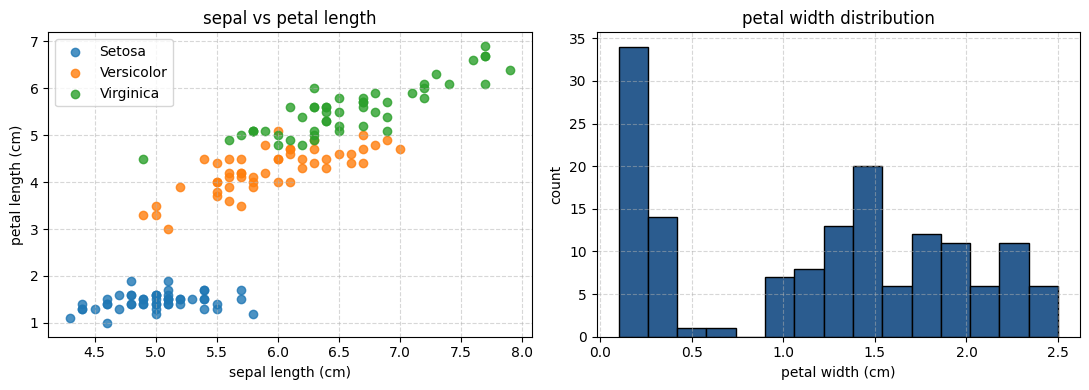

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for species, grp in df.groupby('variety'):
    ax[0].scatter(grp['sepal.length'], grp['petal.length'], label=species, alpha=0.8)
ax[0].set_xlabel('sepal length (cm)')
ax[0].set_ylabel('petal length (cm)')
ax[0].set_title('sepal vs petal length')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.5)

df['petal.width'].hist(ax=ax[1], bins=15, color='#2b5c8f', edgecolor='black')
ax[1].set_xlabel('petal width (cm)')
ax[1].set_ylabel('count')
ax[1].set_title('petal width distribution')
ax[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()